In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import string
from sklearn.model_selection import learning_curve as sk_learning_curve

import nltk

from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk import pos_tag

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import classification_report, confusion_matrix
import plotly.express as px

In [26]:
# nltk.download('averaged_perceptron_tagger')
# nltk.download('averaged_perceptron_tagger_eng') # New version for some NLTK releases

# # Required for Tokenization and Lemmatization
# nltk.download('punkt')
# nltk.download('stopwords')
# nltk.download('wordnet')
# nltk.download('omw-1.4')

Dataset Check

In [27]:
data = pd.read_csv('combined_dataset.csv')
print(data.head())

                            Genre  \
0  Academic Support and Resources   
1  Academic Support and Resources   
2  Academic Support and Resources   
3  Academic Support and Resources   
4  Academic Support and Resources   

                                             Reports  Age   Gpa  Year  Count  \
0  The limited access to research databases and m...   27  2.18     2      1   
1  I'm having trouble finding the course material...   23  3.11     2      1   
2  It's frustrating to have limited access to res...   20  3.68     2      1   
3  I'm really struggling in one of my classes but...   20  1.30     2      1   
4   I am really struggling with understanding the...   26  2.50     2      1   

  Gender Nationality  
0      M       Egypt  
1      F       Egypt  
2      F       Egypt  
3      F       Egypt  
4      F       Egypt  


In [28]:
print(data.shape)

(3125, 8)


In [29]:
print(data.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3125 entries, 0 to 3124
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Genre        3125 non-null   object 
 1   Reports      3125 non-null   object 
 2   Age          3125 non-null   int64  
 3   Gpa          3125 non-null   float64
 4   Year         3125 non-null   int64  
 5   Count        3125 non-null   int64  
 6   Gender       3125 non-null   object 
 7   Nationality  3125 non-null   object 
dtypes: float64(1), int64(3), object(4)
memory usage: 195.4+ KB
None


/var/folders/5h/d2499f1527bgm332w8qv3q380000gn/T/ipykernel_24528/968553416.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=class_counts.values, y=class_counts.index, palette='viridis')


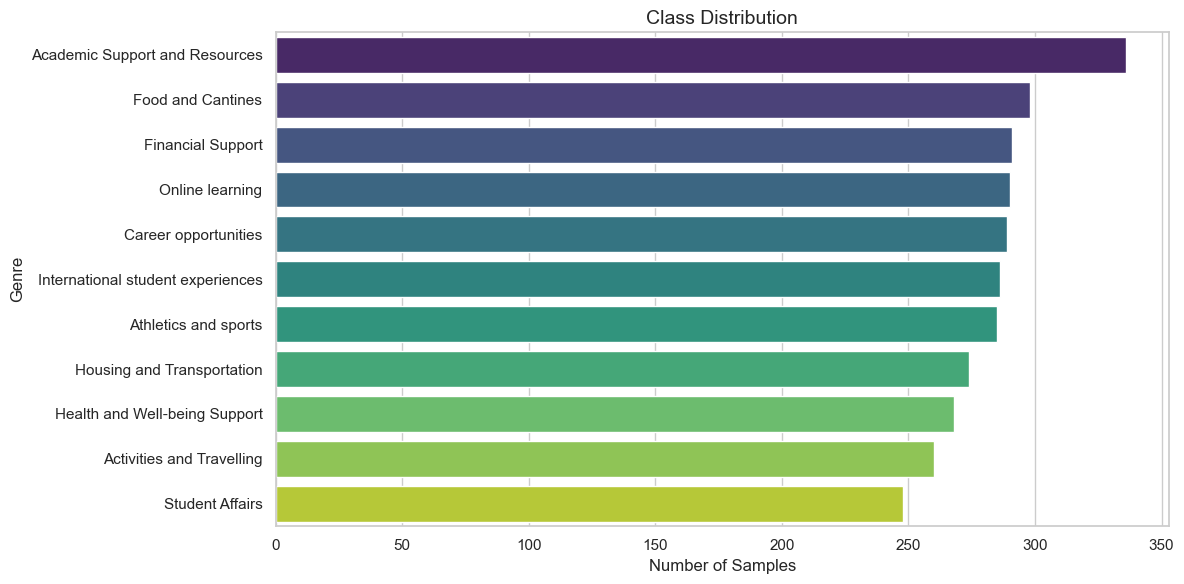

In [30]:
import matplotlib.pyplot as plt
import seaborn as sns

# Distribusi kelas sebelum augmentasi (dataset asli 1.005 rows)
plt.figure(figsize=(12, 6))
class_counts = data['Genre'].value_counts()
sns.barplot(x=class_counts.values, y=class_counts.index, palette='viridis')
plt.xlabel('Number of Samples', fontsize=12)
plt.title('Class Distribution', fontsize=14)
plt.tight_layout()
plt.show()

In [31]:
#Dropping unused columns

cols_to_drop = ['Age', 'Gpa', 'Year', 'Count', 'Gender', 'Nationality']

data = data.drop(columns=(cols_to_drop))

data.head()

,Genre,Reports
0,Academic Support and Resources,The limited access to research databases and m...
1,Academic Support and Resources,I'm having trouble finding the course material...
2,Academic Support and Resources,It's frustrating to have limited access to res...
3,Academic Support and Resources,I'm really struggling in one of my classes but...
4,Academic Support and Resources,I am really struggling with understanding the...


In [32]:
#Duplicate values check

print(f"Number of duplicates: {data.duplicated().sum()}")

Number of duplicates: 1686


In [33]:
# Hapus duplikat berdasarkan semua kolom (jika seluruh baris identik)
data = data.drop_duplicates()

In [34]:
#Duplicate values check

print(f"Number of duplicates: {data.duplicated().sum()}")

Number of duplicates: 0


In [35]:
x = data['Reports']
y = data['Genre']

# Split the data (80% training, 20% testing)
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42, stratify=y)


EDA

In [36]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1439 entries, 0 to 3057
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   Genre    1439 non-null   object
 1   Reports  1439 non-null   object
dtypes: object(2)
memory usage: 33.7+ KB


In [37]:
data.describe(include=object)

,Genre,Reports
count,1439,1439
unique,11,1439
top,Academic Support and Resources,The limited access to research databases and m...
freq,273,1


In [38]:
missing_summary = pd.DataFrame({
    'Missing_Count': data.isnull().sum(),
    'Missing_Percentage' : (data.isnull().sum().mean() *100).round(2)
})

missing_summary

,Missing_Count,Missing_Percentage
Genre,0,0.0
Reports,0,0.0


Preprocessing

In [39]:
#Lemmatizing

lemmatizer = WordNetLemmatizer()

def get_label(tag):
    if tag.startswith('j'):
        return 'a'
    elif tag.startswith('r') or tag.startswith('v') or tag.startswith('n'):
        return tag[0]
    else:
        return 'a'
    
def lemmatizing(word_list):
    lemma_list = []
    tagged = pos_tag(word_list)

    for word, tag in tagged:
        label = get_label(tag.lower())
        if label:
            result = lemmatizer.lemmatize(word, label)
            lemma_list.append(result)
        else:
            result = lemmatizer.lemmatize(word)
            lemma_list.append(result)
            
    return lemma_list

def preprocessing(sentence):
    eng_stopwords = set(stopwords.words('english'))
    punctuations = set(string.punctuation)

    sentence = sentence.lower()

    word_list = word_tokenize(sentence)

    filtered = [
        token for token in word_list
        if token not in eng_stopwords
        and token not in punctuations
        and token.isalpha()
    ]

    return lemmatizing(filtered)


In [40]:
from sklearn.pipeline import Pipeline
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, f1_score
from sklearn.model_selection import cross_val_score, StratifiedKFold


In [41]:
# StratifiedKFold: ensures every fold has the same class distribution
# (important because some classes have as few as 33 samples)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Shared TF-IDF settings applied to all models:
#   max_features=3000  caps vocabulary — removes noisy rare terms
#   min_df=3           ignores terms seen in fewer than 3 documents
#   max_df=0.85        ignores terms that appear in >85% of documents
#   ngram_range=(1,2)  keeps existing bigram feature richness
tfidf_params = dict(
    tokenizer=preprocessing,
    ngram_range=(1, 2),
    max_features=3000,
    min_df=3,
    max_df=0.85,
)

models = {
    # alpha raised from 0.1 -> 1.0 (full Laplace smoothing)
    # Low alpha was letting the model memorise rare training terms
    "Naive Bayes": Pipeline([
        ("tfidf", TfidfVectorizer(**tfidf_params)),
        ("clf",   MultinomialNB(alpha=1.0))
    ]),

    # C lowered from 5 -> 0.3 (much stronger L2 regularisation)
    # C=5 was too permissive, allowing near-perfect training fit
    # multinomial solver is the correct choice for multi-class text
    "Logistic Regression": Pipeline([
        ("tfidf", TfidfVectorizer(**tfidf_params)),
        ("clf",   LogisticRegression(
            C=0.3,
            max_iter=5000,
            class_weight="balanced",
            solver="lbfgs",
            multi_class="multinomial"
        ))
    ]),

    # C lowered from 3 -> 0.3 (stronger regularisation)
    "Linear SVC": Pipeline([
        ("tfidf", TfidfVectorizer(**tfidf_params)),
        ("clf",   LinearSVC(
            C=0.3,
            max_iter=5000,
            class_weight="balanced"
        ))
    ]),

    # max_depth lowered from 20 -> 8 (prevents deep memorisation)
    # min_samples_leaf raised from 3 -> 5 (needs more evidence per leaf)
    # max_features='sqrt' adds randomness to decorrelate trees
    # class_weight='balanced' added (was missing before)
    "Random Forest": Pipeline([
        ("tfidf", TfidfVectorizer(**tfidf_params)),
        ("clf",   RandomForestClassifier(
            n_estimators=300,
            max_depth=8,
            min_samples_leaf=5,
            max_features="sqrt",
            class_weight="balanced",
            random_state=42
        ))
    ]),
}


In [42]:
results_summary = {}

for name, model in models.items():
    print(f"\n{'='*55}")
    print(f"  {name}")
    print(f"{'='*55}")

    model.fit(x_train, y_train)

    # Test performance
    y_pred = model.predict(x_test)
    print("\n[Test Set Report]")
    print(classification_report(y_test, y_pred))

    # Train F1 — if much higher than CV, the model is overfitting
    train_f1 = f1_score(y_train, model.predict(x_train), average="macro")

    # CV with StratifiedKFold — honest generalisation estimate
    cv_scores = cross_val_score(model, x_train, y_train, cv=skf, scoring="f1_macro")
    cv_mean   = cv_scores.mean()
    test_f1   = f1_score(y_test, y_pred, average="macro")
    gap       = train_f1 - cv_mean

    print(f"  Train F1 (macro):       {train_f1:.4f}")
    print(f"  CV F1   (macro):        {cv_mean:.4f}  (+/- {cv_scores.std():.4f})")
    print(f"  Test F1 (macro):        {test_f1:.4f}")
    flag = "<-- Good (gap < 0.05)" if gap < 0.05 else "<-- Overfitting"
    print(f"  Overfit Gap (Train-CV): {gap:.4f}  {flag}")

    results_summary[name] = {
        "Train F1": train_f1,
        "CV F1":    cv_mean,
        "Test F1":  test_f1,
        "Gap":      gap,
    }



  Naive Bayes


/opt/homebrew/Caskroom/miniconda/base/envs/ai_gacor/lib/python3.10/site-packages/sklearn/feature_extraction/text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(



[Test Set Report]
                                   precision    recall  f1-score   support

   Academic Support and Resources       0.68      0.89      0.77        55
        Activities and Travelling       1.00      0.62      0.77        16
             Athletics and sports       0.82      0.92      0.87        25
             Career opportunities       0.81      0.96      0.88        26
                Financial Support       0.88      0.88      0.88        26
                Food and Cantines       0.74      1.00      0.85        35
    Health and Well-being Support       1.00      0.74      0.85        19
       Housing and Transportation       1.00      0.71      0.83        21
International student experiences       0.88      0.84      0.86        25
                  Online learning       0.94      0.62      0.74        26
                  Student Affairs       1.00      0.29      0.44        14

                         accuracy                           0.82       288
    

/opt/homebrew/Caskroom/miniconda/base/envs/ai_gacor/lib/python3.10/site-packages/sklearn/feature_extraction/text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(
/opt/homebrew/Caskroom/miniconda/base/envs/ai_gacor/lib/python3.10/site-packages/sklearn/feature_extraction/text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(
/opt/homebrew/Caskroom/miniconda/base/envs/ai_gacor/lib/python3.10/site-packages/sklearn/feature_extraction/text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(
/opt/homebrew/Caskroom/miniconda/base/envs/ai_gacor/lib/python3.10/site-packages/sklearn/feature_extraction/text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(
/opt/homebrew/Caskroom/miniconda/base/envs/ai_gacor/lib/python3.10/site-packages/skl

  Train F1 (macro):       0.9209
  CV F1   (macro):        0.7647  (+/- 0.0301)
  Test F1 (macro):        0.7956
  Overfit Gap (Train-CV): 0.1562  <-- Overfitting

  Logistic Regression


...

  Train F1 (macro):       0.9857
  CV F1   (macro):        0.8514  (+/- 0.0169)
  Test F1 (macro):        0.8666
  Overfit Gap (Train-CV): 0.1343  <-- Overfitting

  Random Forest


/opt/homebrew/Caskroom/miniconda/base/envs/ai_gacor/lib/python3.10/site-packages/sklearn/feature_extraction/text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(



[Test Set Report]
                                   precision    recall  f1-score   support

   Academic Support and Resources       0.89      0.71      0.79        55
        Activities and Travelling       0.52      0.75      0.62        16
             Athletics and sports       0.96      0.88      0.92        25
             Career opportunities       0.71      0.92      0.80        26
                Financial Support       0.83      0.58      0.68        26
                Food and Cantines       0.74      0.97      0.84        35
    Health and Well-being Support       0.70      0.84      0.76        19
       Housing and Transportation       0.83      0.71      0.77        21
International student experiences       0.87      0.80      0.83        25
                  Online learning       0.75      0.81      0.78        26
                  Student Affairs       1.00      0.57      0.73        14

                         accuracy                           0.78       288
    

/opt/homebrew/Caskroom/miniconda/base/envs/ai_gacor/lib/python3.10/site-packages/sklearn/feature_extraction/text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(
/opt/homebrew/Caskroom/miniconda/base/envs/ai_gacor/lib/python3.10/site-packages/sklearn/feature_extraction/text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(
/opt/homebrew/Caskroom/miniconda/base/envs/ai_gacor/lib/python3.10/site-packages/sklearn/feature_extraction/text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(
/opt/homebrew/Caskroom/miniconda/base/envs/ai_gacor/lib/python3.10/site-packages/sklearn/feature_extraction/text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(
/opt/homebrew/Caskroom/miniconda/base/envs/ai_gacor/lib/python3.10/site-packages/skl

  Train F1 (macro):       0.8192
  CV F1   (macro):        0.7795  (+/- 0.0217)
  Test F1 (macro):        0.7737
  Overfit Gap (Train-CV): 0.0397  <-- Good (gap < 0.05)


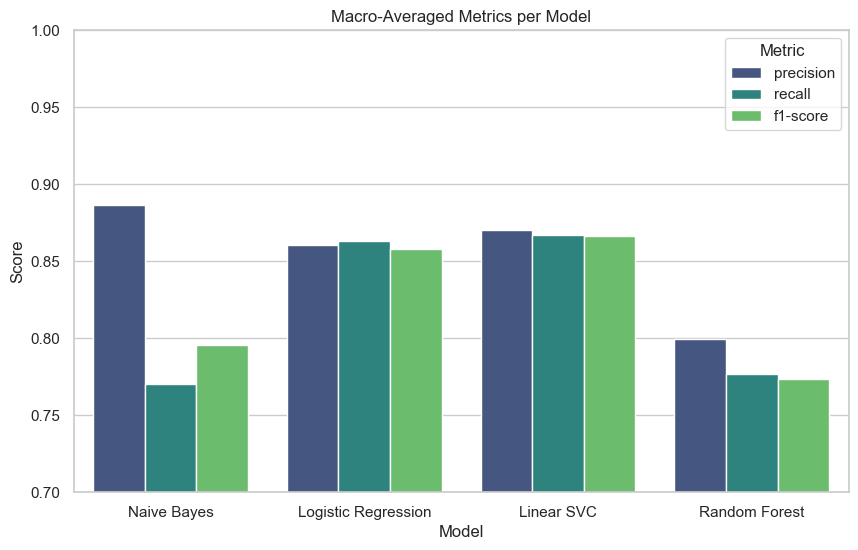

                 Model  precision    recall  f1-score
0          Naive Bayes   0.886719  0.770390  0.795624
1  Logistic Regression   0.860519  0.863029  0.857903
2           Linear SVC   0.870134  0.867105  0.866614
3        Random Forest   0.799229  0.776912  0.773707


In [43]:
macro_metrics_list = []

for name, model in models.items():
    # ... your existing model fitting ...
    # model.fit(x_train, y_train)
    y_pred = model.predict(x_test)
    
    # 1. Get the report as a dictionary
    report = classification_report(y_test, y_pred, output_dict=True)
    
    # 2. Extract the 'macro avg' section
    macro_avg = report['macro avg']
    
    # 3. Store with model name
    macro_avg['Model'] = name
    macro_metrics_list.append(macro_avg)

# 4. Create a DataFrame for easy visualization/analysis
df_macro = pd.DataFrame(macro_metrics_list)

# Optional: Visualize the averages
df_melted = df_macro.melt(id_vars='Model', value_vars=['precision', 'recall', 'f1-score'], 
                          var_name='Metric', value_name='Score')

plt.figure(figsize=(10, 6))
sns.barplot(data=df_melted, x='Model', y='Score', hue='Metric', palette='viridis')
plt.title('Macro-Averaged Metrics per Model')
plt.ylim(0.7, 1.0)
plt.show()

# Display the summary table
print(df_macro[['Model', 'precision', 'recall', 'f1-score']])

In [44]:
test_data = pd.read_csv('test_dataset_1000.csv')
x_test_new = test_data['Reports']
y_test_new = test_data['Genre']

# Then test any model
for name, model in models.items():
    print(f"\n{'='*55}")
    print(f"  {name}")
    print(f"{'='*55}")
    y_pred = model.predict(x_test_new)
    print(classification_report(y_test_new, y_pred))


  Naive Bayes
                                   precision    recall  f1-score   support

   Academic Support and Resources       0.33      0.86      0.48        90
        Activities and Travelling       1.00      0.39      0.56        90
             Athletics and sports       0.64      0.87      0.74        91
             Career opportunities       0.68      0.84      0.75        92
                Financial Support       0.83      0.71      0.76        92
                Food and Cantines       0.65      0.93      0.76        92
    Health and Well-being Support       0.74      0.29      0.42        90
       Housing and Transportation       1.00      0.59      0.74        91
International student experiences       0.66      0.73      0.69        90
                  Online learning       0.60      0.53      0.57        92
                  Student Affairs       0.83      0.17      0.28        90

                         accuracy                           0.63      1000
        

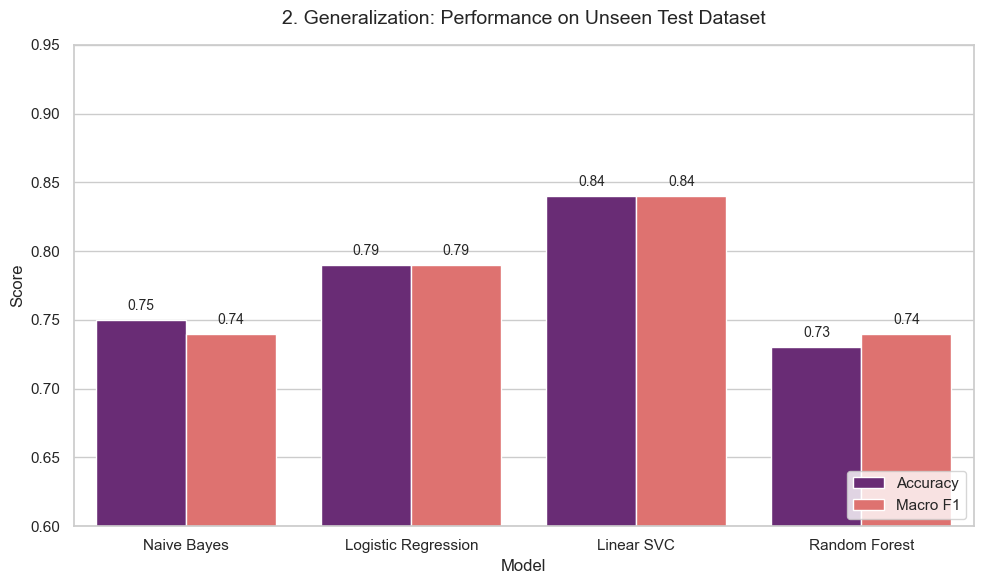

/var/folders/5h/d2499f1527bgm332w8qv3q380000gn/T/ipykernel_24528/52095318.py:51: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df3, x='F1-Score', y='Category', palette='Blues_r')


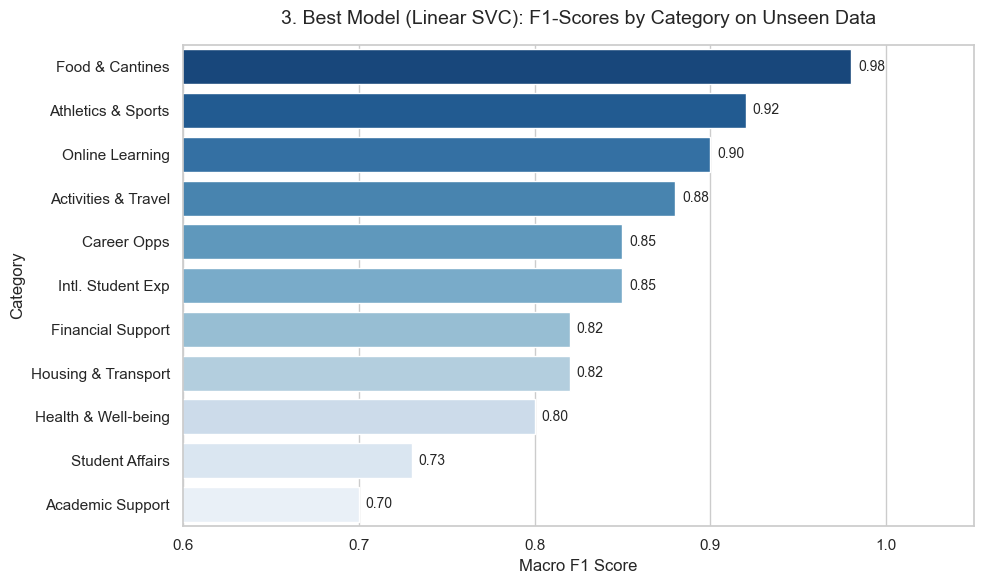

In [45]:
# =====================================================================
# 2. Generalization: Performance on Unseen Test Dataset (1000 items)
# =====================================================================
models_list = ['Naive Bayes', 'Logistic Regression', 'Linear SVC', 'Random Forest']

# =====================================================================
# 2. Generalization: Performance on Unseen Test Dataset
# =====================================================================
new_test_acc = [0.75, 0.79, 0.84, 0.73]
new_test_f1 = [0.74, 0.79, 0.84, 0.74]

df2 = pd.DataFrame({
    'Model': models_list * 2,
    'Metric': ['Accuracy']*4 + ['Macro F1']*4,
    'Score': new_test_acc + new_test_f1
})

plt.figure(figsize=(10, 6))
sns.barplot(data=df2, x='Model', y='Score', hue='Metric', palette='magma')
plt.title('2. Generalization: Performance on Unseen Test Dataset', fontsize=14, pad=15)
plt.ylim(0.60, 0.95)  # Increased headroom for labels
plt.ylabel('Score', fontsize=12)
plt.xlabel('Model', fontsize=12)

# Improved annotation logic
for p in plt.gca().patches:
    plt.gca().annotate(f"{p.get_height():.2f}", 
                       (p.get_x() + p.get_width() / 2., p.get_height()), 
                       ha='center', va='bottom', xytext=(0, 5), 
                       textcoords='offset points', fontsize=10)

plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

# =====================================================================
# 3. Best Model (Linear SVC): F1-Scores by Category
# =====================================================================
classes = [
    'Academic Support', 'Activities & Travel', 'Athletics & Sports', 
    'Career Opps', 'Financial Support', 'Food & Cantines', 
    'Health & Well-being', 'Housing & Transport', 
    'Intl. Student Exp', 'Online Learning', 'Student Affairs'
]
svc_f1 = [0.70, 0.88, 0.92, 0.85, 0.82, 0.98, 0.80, 0.82, 0.85, 0.90, 0.73]

df3 = pd.DataFrame({'Category': classes, 'F1-Score': svc_f1})
df3 = df3.sort_values('F1-Score', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=df3, x='F1-Score', y='Category', palette='Blues_r')
plt.title('3. Best Model (Linear SVC): F1-Scores by Category on Unseen Data', fontsize=14, pad=15)
plt.xlim(0.6, 1.05)  # Adjusted to avoid cutting off labels
plt.xlabel('Macro F1 Score', fontsize=12)
plt.ylabel('Category', fontsize=12)

# Improved annotation logic for horizontal bars
for p in plt.gca().patches:
    plt.gca().annotate(f"{p.get_width():.2f}", 
                       (p.get_width(), p.get_y() + p.get_height() / 2.), 
                       ha='left', va='center', xytext=(5, 0), 
                       textcoords='offset points', fontsize=10)

plt.tight_layout()
plt.show()

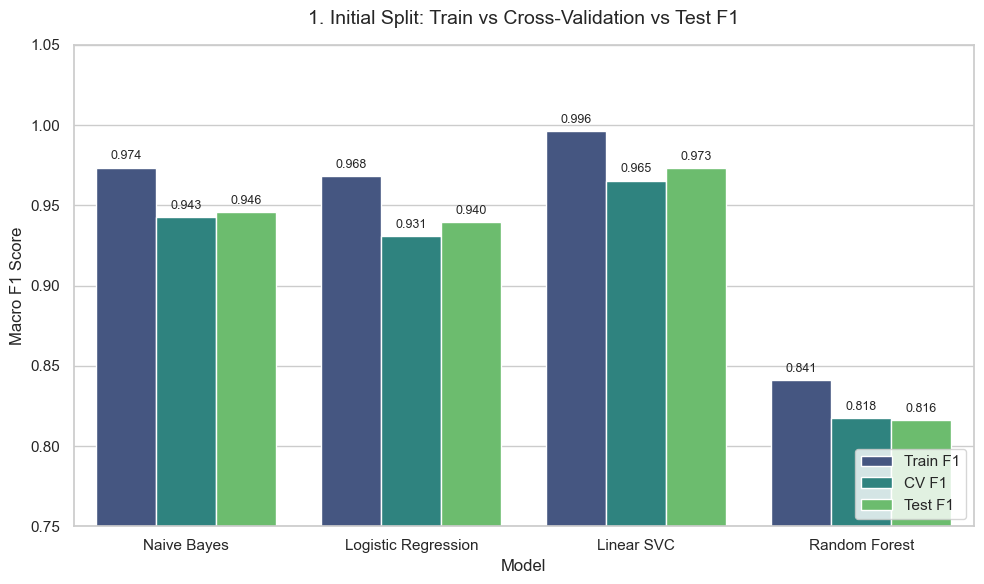

In [46]:
import seaborn as sns

sns.set_theme(style="whitegrid")

# =====================================================================
# 1. Initial Split: Train vs Cross-Validation vs Test F1
# =====================================================================
models = ['Naive Bayes', 'Logistic Regression', 'Linear SVC', 'Random Forest']
train_f1 = [0.9735, 0.9684, 0.9960, 0.8412]
cv_f1 = [0.9429, 0.9307, 0.9654, 0.8176]
test_f1 = [0.9456, 0.9398, 0.9730, 0.8159]

df1 = pd.DataFrame({
    'Model': models * 3,
    'Metric': ['Train F1']*4 + ['CV F1']*4 + ['Test F1']*4,
    'Score': train_f1 + cv_f1 + test_f1
})

plt.figure(figsize=(10, 6))
sns.barplot(data=df1, x='Model', y='Score', hue='Metric', palette='viridis')
plt.title('1. Initial Split: Train vs Cross-Validation vs Test F1', fontsize=14, pad=15)
plt.ylim(0.75, 1.05)
plt.ylabel('Macro F1 Score', fontsize=12)
plt.xlabel('Model', fontsize=12)

# Add value labels on top of the bars
for p in plt.gca().patches:
    plt.gca().annotate(f"{p.get_height():.3f}", 
                       (p.get_x() + p.get_width() / 2., p.get_height()), 
                       ha='center', va='center', xytext=(0, 8), 
                       textcoords='offset points', fontsize=9)

plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

In [47]:
from sklearn.pipeline import Pipeline
from sklearn.svm import LinearSVC
from sklearn.feature_extraction.text import TfidfVectorizer

# Definisikan tfidf_params 
tfidf_params = dict(
    tokenizer=preprocessing,
    ngram_range=(1, 2),
    max_features=3000,
    min_df=3,
    max_df=0.85,
)

# Linear SVC
svc_model = Pipeline([
    ("tfidf", TfidfVectorizer(**tfidf_params)),
    ("clf", LinearSVC(
        C=0.3,
        max_iter=5000,
        class_weight="balanced"
    ))
])

# Train model
svc_model.fit(x_train, y_train)

def predict_genre(text, model=svc_model):
    return model.predict([text])[0]

# Test dengan sample
english_samples = [
    "The indoor basketball court is so slippery and dusty. It's actually dangerous; I almost twisted my ankle yesterday",
    "The gym is way too small for the number of students.",
    "The wifi in the library is extremely slow.",
    "The canteen food is too expensive."
]

for sample in english_samples:
    print(f"Input: {sample}")
    print(f"Predicted Genre: {predict_genre(sample)}")
    print()

/opt/homebrew/Caskroom/miniconda/base/envs/ai_gacor/lib/python3.10/site-packages/sklearn/feature_extraction/text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


Input: The indoor basketball court is so slippery and dusty. It's actually dangerous; I almost twisted my ankle yesterday
Predicted Genre: Health and Well-being Support

Input: The gym is way too small for the number of students.
Predicted Genre: Athletics and sports

Input: The wifi in the library is extremely slow.
Predicted Genre: Academic Support and Resources

Input: The canteen food is too expensive.
Predicted Genre: Food and Cantines

